## ATIVIDADE E PESQUISA PRÁTICA - Classificação de Sentimentos/Análise Comparativa


**Alunos:** Lucas Antonio Cunha Rodrigues da Silva  
            Marcos Vinícius Beregula
            Michel Iago

**Curso:** Ciência de Dados e IA – 3º ano  
**Disciplina:** Aprendizado Supervisionado  
**Professor:** Bruno Faiçal  
**Instituição:** Universidade Estadual de Londrina (UEL)  
**Data:** 05/06/2026  

# Objetivo:
#SITUACIONAL 1 - METODO CONVENCIONAL TF-IDF + MODELO DE PREVISAO (REGRESSAO LOG.)
Automatizar a trigem de avaliações de produtos de um e-commerce, classificando-as
em sentimentos negativos ou positivos.
Removemos as colunas que acreditamos nao terem relacao direta com a avaliacao, e
tambem para isolar a capacidade de previsao com o atributo textual. Pode-se 
questionar se pode haver tendencia de um certo gênero ou faixa etaria avaliar 
mais positiva ou negativamente um produto, mas a ideia do modelo não é capturar 
isso e sim predizer sentimentos através do texto fornecido na avaliação. 
Fizemos os modelos usando a apenas a avaliacao, depois avalicao com †itulo e por
fim avaliacao com título e rating que se mostrou mais eficiente.

#SITUACIONAL 2 - Optamos por utilizar o DISTILLBERT, por ser mais 40% mais leve.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import torch
import torchvision
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from platform import python_branch

In [15]:
#criacao do path de leitura e criacao do dataframe, removendo colunas desnecessarias
caminho = os.getcwd()
arquivo = os.path.join(caminho, 'B2W-Reviews01 - B2W-Reviews01.csv')
df = pd.read_csv(arquivo)

print(f"====== informacoes do dataframe com rating ======")
df.info()

colunas = ['review_title', 'review_text','recommend_to_a_friend','overall_rating']

# quantidade de nulos por coluna (considerando as colunas de interesse)
#ANTES DA REMOÇAO
print(f"==== quantidade de nulos/coluna (apenas colunas de interesse dataframe com rating) ====")
print(df[colunas].isna().sum())

#REMOCAO NULOS
df.dropna(subset=colunas, inplace=True)

#DEPOIS DA REMOÇAO
print(f"==== quantidade nulos/coluna (colunas de interesse apos limpeza dataframe com rating) ====")
print(df[colunas].isna().sum())


#jogamos tudo pra minusculo pra evitar mismatch de rotulos (os atributos ja sao
# tratados pelo vetorizador).

y = df['recommend_to_a_friend'].str.lower().map({'yes': 1, 'no': 0})
df.drop(columns=['reviewer_id','recommend_to_a_friend','submission_date','product_name', 'product_id', 'product_name','product_brand','site_category_lv1','site_category_lv2','reviewer_birth_year','reviewer_gender','reviewer_state'], inplace=True)

print(f"==== INFO DATAFRAME COM RATING APOS LIMPEZA E REMOCAO COLUNAS DESNECESSARIAS ====")
df.info()

print(f"==== DATAFRAME COM RATING ====")
display(df)

====== informacoes do dataframe com rating ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   submission_date        132373 non-null  object 
 1   reviewer_id            132373 non-null  object 
 2   product_id             132373 non-null  object 
 3   product_name           132289 non-null  object 
 4   product_brand          40982 non-null   object 
 5   site_category_lv1      132367 non-null  object 
 6   site_category_lv2      128360 non-null  object 
 7   review_title           132070 non-null  object 
 8   recommend_to_a_friend  132355 non-null  object 
 9   review_text            129098 non-null  object 
 10  overall_rating         132373 non-null  int64  
 11  reviewer_birth_year    126389 non-null  float64
 12  reviewer_gender        128237 non-null  object 
 13  reviewer_state         128382 non-null 

/var/folders/54/fr9l7bd94ng5bc0gv_kvlsvh0000gn/T/ipykernel_27080/346423635.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)


,review_title,review_text,overall_rating
0,Bom,Estou contente com a compra entrega rápida o ú...,4
1,"Preço imbatível, ótima qualidade","Por apenas R$1994.20,eu consegui comprar esse ...",4
2,ATENDE TODAS AS EXPECTATIVA.,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4
3,presente mais que desejado,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4
4,"Sem duvidas, excelente","A entrega foi no prazo, as americanas estão de...",5
...,...,...,...
132368,Ótimo produto!,"Vale muito, estou usando no controle do Xbox e...",5
132369,Sensacional,"Prático e barato, super indico o produto para ...",5
132370,Ótimo produto,Chegou antes do prazo previsto e corresponde a...,4
132371,O produto não é bom.,"Material fraco, poderia ser melhor. Ficou deve...",1


In [16]:
#criacao de uma coluna com o titulo e avaliacao agregados para comparacao

df["review_plus_title"] = df["review_title"].astype(str) + " " + df["review_text"].astype(str)
ratings = df["overall_rating"]
#STOP WORDS
stop_words_pt = stopwords.words("portuguese")

#criacao do vetorizador de palavras e criacao do modelo de regressao logistica

vectorizer_review = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words=stop_words_pt
    #mudando pra english nao alterou em nada as metricas
    
)

vectorizer_full = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words=stop_words_pt
    #corrigir aqui pra portugues
)

review = df['review_text']
review_plus_title = df['review_plus_title']

# y foi capturado no bloco anterior

#holdout pra treinamento do modelo, fazemos duas vezes pra garantir a validacao
#uma alimenta a outra pra poder validar o modelo.
#do total, 20% vira TESTE e 80% vira TREINO
(
    X_train_review,
    X_test_review,
    X_train_full,
    X_test_full,
    X_rating_train_temp,
    X_rating_test,
    y_train_temp,
    y_test,
) = train_test_split(
    review,             
    review_plus_title,
    ratings,   
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Dos 80% para treino, 20% vira VALIDACAO. Note teste nao entra nesta etapa.
(
    X_train_review,
    X_val_review,
    X_train_full,
    X_val_full,
    X_rating_train,
    X_rating_val,
    y_train,
    y_val,
) = train_test_split(
    X_train_review,
    X_train_full,
    X_rating_train_temp,
    y_train_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_train_temp,
)



#fit_transform para treino e transform para teste ATENCAO!!!!

#avaliacao apenas
#treino
X_train_review_only = vectorizer_review.fit_transform(X_train_review)
#teste
X_test_review_only = vectorizer_review.transform(X_test_review)
#avaliacao apenas (validacao)
X_val_review_only = vectorizer_review.transform(X_val_review)

#avaliacao com titulo
#treino
X_train_title_plus_review = vectorizer_full.fit_transform(X_train_full)
#teste  
X_test_title_plus_review = vectorizer_full.transform(X_test_full)
#(validacao)


X_val_title_plus_review = vectorizer_full.transform(X_val_full)

#preparativos pra fazer titulo+avaliacao+rating
#preparacao pra poder contatenar a matriz esparsa com o rating - HSTACK
scaler_rating = StandardScaler()
r_train = scaler_rating.fit_transform(X_rating_train.to_numpy().reshape(-1, 1))
r_val   = scaler_rating.transform(X_rating_val.to_numpy().reshape(-1, 1))
r_test  = scaler_rating.transform(X_rating_test.to_numpy().reshape(-1, 1))

# avaliacao com titulo e rating — mesmos nomes que você quer
X_train_over_filled = hstack([X_train_title_plus_review, r_train])
X_test_over_filled  = hstack([X_test_title_plus_review, r_test])
X_val_over_filled   = hstack([X_val_title_plus_review, r_val])

#treinamento dos modelos
#TREINO - avaliacao apenas
modelo_review_only = LogisticRegression(max_iter=1000)
modelo_review_only.fit(X_train_review_only, y_train)

#TREINO avaliacao com titulo
modelo_title_plus_review = LogisticRegression(max_iter=1000)
modelo_title_plus_review.fit(X_train_title_plus_review, y_train)

#TREINO - avaliacao com titulo e rating
modelo_text_plus_rating = LogisticRegression(max_iter=1000)
modelo_text_plus_rating.fit(X_train_over_filled, y_train)

#TREINO - apenas pra avaliacao do modelo (verificar overfitting)

predicoes_treino_review_only = modelo_review_only.predict(X_train_review_only)
predicoes_treino_title_plus_review = modelo_title_plus_review.predict(X_train_title_plus_review)
predicoes_treino_over_filled = modelo_text_plus_rating.predict(X_train_over_filled)

#validacao dos modelos
predicoes_val_review_only = modelo_review_only.predict(X_val_review_only)
predicoes_val_title_plus_review = modelo_title_plus_review.predict(X_val_title_plus_review)
predicoes_val_over_filled = modelo_text_plus_rating.predict(X_val_over_filled)

#teste do modelo
predicoes_review_only = modelo_review_only.predict(X_test_review_only)
predicoes_title_plus_review = modelo_title_plus_review.predict(X_test_title_plus_review)
predicoes_over_filled = modelo_text_plus_rating.predict(X_test_over_filled)

print(f"==== CLASSIFICACAO USANDO AVALIACAO - ETAPA TREINO ====")
print(classification_report(y_train, predicoes_treino_review_only))
print(f"==== MATRIZ DE CONFUSÃO USANDO AVALIACAO - ETAPA TREINO ====")
print(confusion_matrix(y_train, predicoes_treino_review_only))
print(f"==== ACURACIA USANDO AVALIACAO - ETAPA TREINO ====")
print(accuracy_score(y_train, predicoes_treino_review_only))

print(f"==== CLASSIFICACAO COM TITULO E AVALIACAO - ETAPA TREINO ====")
print(classification_report(y_train, predicoes_treino_title_plus_review))
print(f"==== MATRIZ DE CONFUSÃO USANDO TITULO E AVALIACAO - ETAPA TREINO ====")
print(confusion_matrix(y_train, predicoes_treino_title_plus_review))
print(f"==== ACURACIA USANDO TITULO E AVALIACAO - ETAPA TREINO ====")
print(accuracy_score(y_train, predicoes_treino_title_plus_review))

print(f"==== CLASSIFICACAO COM TITULO, AVALIACAO E RATING - ETAPA TREINO ====")
print(classification_report(y_train, predicoes_treino_over_filled))
print(f"==== MATRIZ DE CONFUSÃO USANDO TITULO, AVALIACAO E RATING - ETAPA TREINO ====")
print(confusion_matrix(y_train, predicoes_treino_over_filled))
print(f"==== ACURACIA USANDO TITULO, AVALIACAO E RATING - ETAPA TREINO ====")
print(accuracy_score(y_train, predicoes_treino_over_filled))

print(f"==== CLASSIFICACAO USANDO AVALIACAO - ETAPA VALIDACAO ====")
print(classification_report(y_val, predicoes_val_review_only))
print(f"==== MATRIZ DE CONFUSÃO USANDO AVALIACAO - ETAPA VALIDACAO ====")
print(confusion_matrix(y_val, predicoes_val_review_only))
print(f"==== ACURACIA USANDO AVALIACAO - ETAPA VALIDACAO ====")
print(accuracy_score(y_val, predicoes_val_review_only))

print(f"==== CLASSIFICACAO COM TITULO E AVALIACAO - ETAPA VALIDACAO ====")
print(classification_report(y_val, predicoes_val_title_plus_review))
print(f"==== MATRIZ DE CONFUSÃO COM TITULO E AVALIACAO - ETAPA VALIDACAO ====")
print(confusion_matrix(y_val, predicoes_val_title_plus_review))
print(f"==== ACURACIA COM TITULO E AVALIACAO - ETAPA VALIDACAO ====")
print(accuracy_score(y_val, predicoes_val_title_plus_review))

print(f"==== CLASSIFICACAO COM TITULO, AVALIACAO E RATING - ETAPA VALIDACAO ====")
print(classification_report(y_val, predicoes_val_over_filled))
print(f"==== MATRIZ DE CONFUSÃO COM TITULO, AVALIACAO E RATING - ETAPA VALIDACAO ====")
print(confusion_matrix(y_val, predicoes_val_over_filled))
print(f"==== ACURACIA COM TITULO, AVALIACAO E RATING - ETAPA VALIDACAO ====")
print(accuracy_score(y_val, predicoes_val_over_filled))

print(f"==== CLASSIFICACAO USANDO AVALIACAO - ETAPA TESTE ====")
print(classification_report(y_test, predicoes_review_only))
print(f"==== MATRIZ DE CONFUSÃO USANDO AVALIACAO - ETAPA TESTE ====")
print(confusion_matrix(y_test, predicoes_review_only))
print(f"==== ACURACIA USANDO AVALIACAO - ETAPA TESTE ====")
print(accuracy_score(y_test, predicoes_review_only))

print(f"==== CLASSIFICACAO COM TITULO E AVALIACAO - ETAPA TESTE ====")
print(classification_report(y_test, predicoes_title_plus_review))
print(f"==== MATRIZ DE CONFUSÃO COM TITULO E AVALIACAO - ETAPA TESTE ====")
print(confusion_matrix(y_test, predicoes_title_plus_review))
print(f"==== ACURACIA COM TITULO E AVALIACAO - ETAPA TESTE ====")
print(accuracy_score(y_test, predicoes_title_plus_review))

print(f"==== CLASSIFICACAO COM TITULO, AVALIACAO E RATING - ETAPA TESTE ====")
print(classification_report(y_test, predicoes_over_filled))
print(f"==== MATRIZ DE CONFUSÃO COM TITULO, AVALIACAO E RATING - ETAPA TESTE ====")
print(confusion_matrix(y_test, predicoes_over_filled))
print(f"==== ACURACIA COM TITULO, AVALIACAO E RATING - ETAPA TESTE ====")
print(accuracy_score(y_test, predicoes_over_filled))


/opt/anaconda3/envs/sentimentos_novo/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ate', 'eramos', 'estao', 'estavamos', 'estiveramos', 'estivessemos', 'foramos', 'fossemos', 'ha', 'hao', 'houveramos', 'houverao', 'houveriamos', 'houvessemos', 'ja', 'nao', 'sao', 'sera', 'serao', 'seriamos', 'so', 'tambem', 'tera', 'terao', 'teriamos', 'tinhamos', 'tiveramos', 'tivessemos', 'voce', 'voces'] not in stop_words.
  warnings.warn(


==== CLASSIFICACAO USANDO AVALIACAO - ETAPA TREINO ====
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     21725
           1       0.94      0.96      0.95     60738

    accuracy                           0.93     82463
   macro avg       0.91      0.90      0.91     82463
weighted avg       0.93      0.93      0.93     82463

==== MATRIZ DE CONFUSÃO USANDO AVALIACAO - ETAPA TREINO ====
[[18156  3569]
 [ 2356 58382]]
==== ACURACIA USANDO AVALIACAO - ETAPA TREINO ====
0.9281495943635327
==== CLASSIFICACAO COM TITULO E AVALIACAO - ETAPA TREINO ====
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     21725
           1       0.96      0.97      0.96     60738

    accuracy                           0.94     82463
   macro avg       0.93      0.92      0.92     82463
weighted avg       0.94      0.94      0.94     82463

==== MATRIZ DE CONFUSÃO USANDO TITULO E AVALIACAO - ETAPA TREINO =

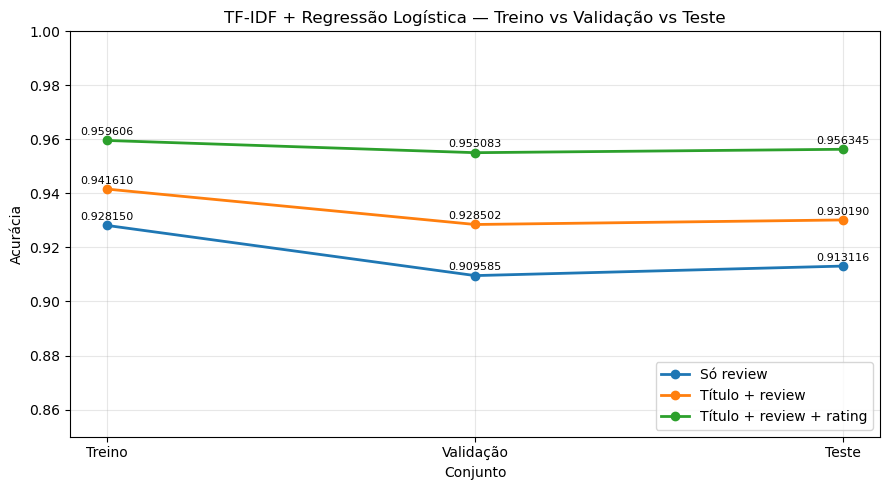

In [18]:
#visualizacao do desempenho do modelo criado
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Nome do modelo -> (y e pred) para treino, val e teste
resultados = {
    "Só review": [
        (y_train, predicoes_treino_review_only),
        (y_val, predicoes_val_review_only),
        (y_test, predicoes_review_only),
    ],
    "Título + review": [
        (y_train, predicoes_treino_title_plus_review),
        (y_val, predicoes_val_title_plus_review),
        (y_test, predicoes_title_plus_review),
    ],
    "Título + review + rating": [
        (y_train, predicoes_treino_over_filled),
        (y_val, predicoes_val_over_filled),
        (y_test, predicoes_over_filled),
    ],
}

conjuntos = ["Treino", "Validação", "Teste"]

plt.figure(figsize=(9, 5))

for nome_modelo, pares in resultados.items():
    accs = [accuracy_score(y, pred) for y, pred in pares]
    plt.plot(conjuntos, accs, marker="o", linewidth=2, label=nome_modelo)
    for x, a in zip(conjuntos, accs):
        plt.text(x, a + 0.002, f"{a:.6f}", ha="center", fontsize=8)

plt.ylim(0.85, 1.0)  # ajuste se suas acurácias forem menores
plt.ylabel("Acurácia")
plt.xlabel("Conjunto")
plt.title("TF-IDF + Regressão Logística — Treino vs Validação vs Teste")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SEGUNDO SITUACIONAL - Abordagem Baseada em Aprendizado Profundo (Deep Learning):
Como observamos anteriormente que a capacidade preditiva das colunas titulo e 
review é superior quando agregadas iremos usar ambas informações no nosso modelo.

In [4]:
#declarando as variaveis de configuracao do modelo
MODELO = "distilbert/distilbert-base-multilingual-cased"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 2
RANDOM_STATE = 42
N_TREINO_BERT = 5000  # aumentar caso nao travar

In [5]:
#CRIACAO DOS CONJUNTOS PARA TREINO E TESTE USANDO OS MESMOS GRUPOS DA ETAPA1
df_tr = pd.DataFrame({
    "text": X_train_full.astype(str),
    "label": y_train.values,
})

df_tr_sub, _ = train_test_split(
    df_tr,
    train_size=min(N_TREINO_BERT, len(df_tr)),
    stratify=df_tr["label"],
    random_state=RANDOM_STATE,
)

texto_treino_bert = df_tr_sub["text"].tolist()
y_treino_bert = df_tr_sub["label"].tolist()

texto_val_bert = X_val_full.astype(str).tolist()
y_val_bert = y_val.tolist()

texto_teste_bert = X_test_full.astype(str).tolist()
y_teste_bert = y_test.tolist()

print(len(texto_treino_bert), len(texto_val_bert), len(texto_teste_bert))

5000 20616 25770


In [6]:
#TOKENIZACAO E CARREGAMENTO DO MODELO

tokenizer = AutoTokenizer.from_pretrained(MODELO)

model_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELO,
    num_labels=2,
)

#DURANTE A PRIMEIRA EXECUCAO IRA BAIXAR DO HUB E SALVAR NO CACHE

#classe criacao dataset pytorch
class ReviewDataset(Dataset):
    def __init__(self, textos, labels):
        self.encodings = tokenizer(
            list(textos),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

#usa a classe criada para converter os dados em pytorch
train_dataset = ReviewDataset(texto_treino_bert, y_treino_bert)
val_dataset = ReviewDataset(texto_val_bert, y_val_bert)
test_dataset = ReviewDataset(texto_teste_bert, y_teste_bert)




Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12904.76it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#TREINAMENTO DO MODELO COM O DATASET CRIADO
#CONFIGURACOES: 2 EPOCAS E BATCH SIZE 8

training_args = TrainingArguments(
    output_dir="./distilbert_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    learning_rate=2e-5,
    seed=RANDOM_STATE,
    report_to="none",
)

trainer = Trainer(
    model=model_distil,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

/opt/anaconda3/envs/sentimentos_novo/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.257755,0.251369
2,0.205464,0.268998


TrainOutput(global_step=1250, training_loss=0.26896224975585936, metrics={'train_runtime': 484.2589, 'train_samples_per_second': 20.65, 'train_steps_per_second': 2.581, 'total_flos': 331168496640000.0, 'train_loss': 0.26896224975585936, 'epoch': 2.0})

In [8]:
out_test = trainer.predict(test_dataset)
y_pred_distil = np.argmax(out_test.predictions, axis=1)

print("==== DISTILBERT - TESTE ====")
print(classification_report(y_teste_bert, y_pred_distil))
print(confusion_matrix(y_teste_bert, y_pred_distil))
print("Acurácia:", accuracy_score(y_teste_bert, y_pred_distil))

==== DISTILBERT - TESTE ====
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      6789
           1       0.95      0.95      0.95     18981

    accuracy                           0.92     25770
   macro avg       0.90      0.90      0.90     25770
weighted avg       0.92      0.92      0.92     25770

[[ 5835   954]
 [ 1017 17964]]
Acurácia: 0.9235157159487777
